## Импорты и настройки окружения

In [4]:
import os
import warnings

import pandas as pd
from dotenv import load_dotenv
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold

import mlflow
import mlflow.catboost
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

import optuna

from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import cross_val_score
import time

warnings.filterwarnings("ignore")
load_dotenv()

True

In [5]:
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID", "admin")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY", "password")
raw_s3_endpoint = os.getenv("MLFLOW_S3_ENDPOINT_URL", "http://localhost:9000")

if "minio:9000" in raw_s3_endpoint:
    raw_s3_endpoint = "http://localhost:9000"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = raw_s3_endpoint

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5050")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("MLflow URI:", mlflow.get_tracking_uri())

MLflow URI: http://localhost:5050


In [6]:
# Быстрая проверка подключения
mlflow.search_experiments(max_results=2)

[<Experiment: artifact_location='mlflow-artifacts:/', creation_time=1780227321568, experiment_id='1', last_update_time=1780227321568, lifecycle_stage='active', name='audio-catboost', tags={}>]

## Чтение датасета

In [7]:
df = pd.read_feather('./data/df_prep_model')

X, y = df.drop('major_mood_class', axis=1), df['major_mood_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("train:", X_train.shape, "test:", X_test.shape)

train: (10922, 86) test: (4681, 86)


In [8]:
splitter = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

## Настройка эксперимента и запуск run

In [7]:
experiment_name = "audio-catboost"
artifact_location = "mlflow-artifacts:/"
client = MlflowClient()

exp = mlflow.get_experiment_by_name(experiment_name)

if exp is None:
    exp_id = client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_location
    )
    print("Created experiment:", exp_id)
else:
    exp_id = exp.experiment_id
    print("Using existing experiment:", exp_id, "artifact_location=", exp.artifact_location)

mlflow.set_experiment(experiment_name)

registered_model_name = "audio_catboost"

Created experiment: 1


In [8]:
def objective_cb(trial):
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}"):

        bootstrap_type = trial.suggest_categorical(
            'bootstrap_type',
            ['Bayesian', 'Bernoulli']
        )

        params = {
            'iterations': trial.suggest_int('iterations', 1000, 3000),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1),
            'depth': trial.suggest_int('depth', 4, 6),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 500, 30),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 30),
            'bootstrap_type': bootstrap_type,
            'auto_class_weights': trial.suggest_categorical(
                'auto_class_weights', ['Balanced', 'SqrtBalanced', None]
            ),
            'random_seed': 42,
            'verbose': False
        }

        if bootstrap_type == 'Bayesian':
            params['bagging_temperature'] = trial.suggest_float(
                "bagging_temperature", 0, 10
            )
        else:
            params['subsample'] = trial.suggest_float(
                'subsample', 0.5, 1.0
            )

        model = CatBoostClassifier(**params)
        
        score = cross_val_score(
            model, X_train, y_train, cv=splitter, scoring='f1_macro'
        ).mean()
        
        mlflow.log_params(params)
        mlflow.log_metric("f1_macro_test", score)

        return score

In [9]:
with mlflow.start_run(run_name="Catboost with optuna"):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_cb, n_trials=20, timeout=3600, show_progress_bar=True)

[I 2026-05-31 14:35:48,852] A new study created in memory with name: no-name-fa8cbd8b-c857-4ca1-81bf-e7aeed2e86ad
Best trial: 0. Best value: 0.292118:   5%|▌         | 1/20 [05:27<1:43:40, 327.37s/it, 327.37/3600 seconds]

🏃 View run trial_0 at: http://localhost:5050/#/experiments/1/runs/18c6d6471d9f4b61a56fe46915f3cafe
🧪 View experiment at: http://localhost:5050/#/experiments/1
[I 2026-05-31 14:41:16,220] Trial 0 finished with value: 0.29211813937729325 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 2712, 'learning_rate': 0.057018331343521356, 'depth': 5, 'min_data_in_leaf': 260, 'l2_leaf_reg': 29.354010386896384, 'auto_class_weights': None, 'subsample': 0.8846686768503109}. Best is trial 0 with value: 0.29211813937729325.


Best trial: 0. Best value: 0.292118:  10%|█         | 2/20 [10:29<1:33:47, 312.66s/it, 629.73/3600 seconds]

🏃 View run trial_1 at: http://localhost:5050/#/experiments/1/runs/ebc05fc3d7784dedbde859c985299e46
🧪 View experiment at: http://localhost:5050/#/experiments/1
[I 2026-05-31 14:46:18,585] Trial 1 finished with value: 0.2636570901388415 and parameters: {'bootstrap_type': 'Bernoulli', 'iterations': 2493, 'learning_rate': 0.023988643931313308, 'depth': 5, 'min_data_in_leaf': 110, 'l2_leaf_reg': 29.608456044723503, 'auto_class_weights': None, 'subsample': 0.8215584637462616}. Best is trial 0 with value: 0.29211813937729325.


Best trial: 2. Best value: 0.317473:  15%|█▌        | 3/20 [11:45<57:59, 204.69s/it, 705.95/3600 seconds]  

...

Best trial: 11. Best value: 0.338385:  70%|███████   | 14/20 [57:22<18:30, 185.11s/it, 3442.94/3600 seconds]

🏃 View run trial_13 at: http://localhost:5050/#/experiments/1/runs/44d7ac94904548d19a72c41ca3b5bfd6
🧪 View experiment at: http://localhost:5050/#/experiments/1
[I 2026-05-31 15:33:11,781] Trial 13 finished with value: 0.324754237701075 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 1936, 'learning_rate': 0.06866521592411168, 'depth': 4, 'min_data_in_leaf': 170, 'l2_leaf_reg': 1.2149917949196665, 'auto_class_weights': 'SqrtBalanced', 'bagging_temperature': 2.4547813327015837}. Best is trial 11 with value: 0.33838471725195785.


Best trial: 14. Best value: 0.344789:  75%|███████▌  | 15/20 [1:00:23<20:07, 241.55s/it, 3623.19/3600 seconds]

🏃 View run trial_14 at: http://localhost:5050/#/experiments/1/runs/1c199dfe4ad447f7ad82832cd540c8e0
🧪 View experiment at: http://localhost:5050/#/experiments/1
[I 2026-05-31 15:36:12,035] Trial 14 finished with value: 0.3447887900342413 and parameters: {'bootstrap_type': 'Bayesian', 'iterations': 2269, 'learning_rate': 0.08363652165634591, 'depth': 4, 'min_data_in_leaf': 50, 'l2_leaf_reg': 7.157030676088805, 'auto_class_weights': 'Balanced', 'bagging_temperature': 8.598975659504145}. Best is trial 14 with value: 0.3447887900342413.


🏃 View run Catboost with optuna at: http://localhost:5050/#/experiments/1/runs/2fce6ab8bac74cca9fb2ee1a88d92ce5
🧪 View experiment at: http://localhost:5050/#/experiments/1


In [11]:
best_params = study.best_params
best_params

{'bootstrap_type': 'Bayesian',
 'iterations': 2269,
 'learning_rate': 0.08363652165634591,
 'depth': 4,
 'min_data_in_leaf': 50,
 'l2_leaf_reg': 7.157030676088805,
 'auto_class_weights': 'Balanced',
 'bagging_temperature': 8.598975659504145}

In [ ]:
# Так как перебирали для демонстрации mlflow лишь часть пораметров и гораниченное время, возьмем параметры из прошлого чекпойнта

best_params = {
    'bootstrap_type': 'Bernoulli', 
    'iterations': 2956, 
    'learning_rate': 0.0310538950276291, 
    'depth': 6, 
    'min_data_in_leaf': 420, 
    'l2_leaf_reg': 21.44173209106835, 
    'random_strength': 6.185851666691056, 
    'rsm': 0.7141469821965828, 
    'auto_class_weights': 'Balanced', 
    'subsample': 0.899917909719124,
    'random_seed': 42
    
    }

In [ ]:
with mlflow.start_run(experiment_id=exp_id):
    print("Artifact URI for this run:", mlflow.get_artifact_uri())
    model = CatBoostClassifier(**best_params, custom_metric=["TotalF1:average=Macro"], use_best_model=True)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=300)

    results = model.get_evals_result()

    for step, f1 in enumerate(
        results["validation"]["TotalF1:average=Macro;use_weights=false"]
    ):
        mlflow.log_metric(
            "f1_test_dynamic",
            f1,
            step=step
        )

    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)

    metrics = {
        "f1_train": float(f1_score(y_train, preds_train, average='macro')),
        "f1_test": float(f1_score(y_test, preds_test, average='macro')),
    }

    mlflow.log_params(best_params)
    mlflow.log_metrics(metrics)
    
    mlflow.log_metric(
        "tree_count",
        model.tree_count_
    )


    model_info = mlflow.catboost.log_model(
        cb_model=model,
        artifact_path="catboost_model",
        input_example=X_test.head(5),
        registered_model_name=registered_model_name
    )

    mlflow.log_input(
        mlflow.data.from_pandas(df, source="./data/df_prep_model"),
        context="training",
    )

    # Маркируем текущую версию как PRD в реестре моделей
    client = MlflowClient()
    new_version = model_info.registered_model_version
    client.set_model_version_tag(registered_model_name, new_version, "env", "PRD")
    client.set_registered_model_alias(registered_model_name, "prd", new_version)

    run_id = mlflow.active_run().info.run_id

    client.set_tag(
        run_id,
        "best_model",
        "true"
    )

    print("Run ID:", run_id)
    print("Registered model version:", new_version)
    print("Alias 'prd' points to version:", new_version)
    print("Metrics:", metrics)


Artifact URI for this run: mlflow-artifacts:/68a201c16fce4f778524d4f402a9082e/artifacts
0:	learn: 1.7895787	test: 1.7904266	best: 1.7904266 (0)	total: 28.4ms	remaining: 1m 24s
300:	learn: 1.5307274	test: 1.6514037	best: 1.6514037 (300)	total: 11.6s	remaining: 1m 42s
600:	learn: 1.3592554	test: 1.6047665	best: 1.6047665 (600)	total: 31.8s	remaining: 2m 4s
900:	learn: 1.2393231	test: 1.5891856	best: 1.5890447 (889)	total: 1m 1s	remaining: 2m 19s
1200:	learn: 1.1412435	test: 1.5817943	best: 1.5816947 (1199)	total: 1m 30s	remaining: 2m 11s
1500:	learn: 1.0598492	test: 1.5782966	best: 1.5782781 (1494)	total: 1m 59s	remaining: 1m 55s
1800:	learn: 0.9901983	test: 1.5789653	best: 1.5778978 (1531)	total: 2m 28s	remaining: 1m 35s
2100:	learn: 0.9301491	test: 1.5823992	best: 1.5778978 (1531)	total: 2m 56s	remaining: 1m 11s
2400:	learn: 0.8765631	test: 1.5841784	best: 1.5778978 (1531)	total: 3m 25s	remaining: 47.4s
2700:	learn: 0.8264131	test: 1.5892392	best: 1.5778978 (1531)	total: 3m 53s	remaini

2026/05/31 16:38:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/31 16:38:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\aleks\OneDrive\Рабочий стол\HSE\Годовой проект\MLflow
2026/05/31 16:38:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\aleks\OneDrive\Рабочий стол\HSE\Годовой проект\MLflow
2026/05/31 16:38:07 INFO mlflow.utils.environment: Detected uv project at c:\Users\aleks\OneDrive\Рабочий стол\HSE\Годовой проект\MLflow. Attempting to export requirements via 'uv export'.
2026/05/31 16:38:07 WARNING mlflow.utils.uv_utils: uv is not available or version is below minimum required. Falling back to pip-based inference.
2026/05/31 16:38:07 WARNING mlflow.utils.environment: uv export failed or returned no requirements. Falling back to package capture based inference.
2026/05/31 16:38:11 WARNING mlflow.utils.environment: Failed to resolve i

Run ID: 68a201c16fce4f778524d4f402a9082e
Registered model version: 3
Alias 'prd' points to version: 3
Metrics: {'f1_train': 0.643612839884088, 'f1_test': 0.3469613805262433}
🏃 View run shivering-cow-304 at: http://localhost:5050/#/experiments/1/runs/68a201c16fce4f778524d4f402a9082e
🧪 View experiment at: http://localhost:5050/#/experiments/1


## Проверка результатов в MLflow

In [ ]:
runs_df = mlflow.search_runs(
    experiment_names=[experiment_name],
    order_by=["metrics.f1_test DESC"],
)
runs_df[["run_id", "metrics.f1_train", "metrics.f1_test", "artifact_uri"]].head()

In [50]:
# Показать запуски
mlflow.search_runs(experiment_names=[experiment_name])

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.f1_test,metrics.tree_count,metrics.f1_train,metrics.f1_test_dynamic,...,params.random_strength,params.bagging_temperature,params.verbose,tags.mlflow.runName,tags.mlflow.user,tags.best_model,tags.mlflow.source.git.commit,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.parentRunId
0,68a201c16fce4f778524d4f402a9082e,1,FINISHED,mlflow-artifacts:/68a201c16fce4f778524d4f402a9...,2026-05-31 13:28:05.864000+00:00,2026-05-31 13:38:18.601000+00:00,0.346961,1532.0,0.643613,0.349637,...,6.185851666691056,None,None,shivering-cow-304,aleks,true,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,None
1,35cd789df2944fbba713cb0a20d0a217,1,FAILED,mlflow-artifacts:/35cd789df2944fbba713cb0a20d0...,2026-05-31 13:27:53.384000+00:00,2026-05-31 13:27:58.590000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,useful-tern-555,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,None
2,69c2247ac45c4e13a7f53ad05feec97d,1,FINISHED,mlflow-artifacts:/69c2247ac45c4e13a7f53ad05fee...,2026-05-31 13:16:48.907000+00:00,2026-05-31 13:25:59.099000+00:00,0.349447,1747.0,0.666103,0.354553,...,6.185851666691056,None,None,loud-roo-544,aleks,true,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,None
3,7e2ff308731849ed908c02389fcc2ea1,1,FINISHED,mlflow-artifacts:/7e2ff308731849ed908c02389fcc...,2026-05-31 12:57:00.084000+00:00,2026-05-31 12:57:49.640000+00:00,0.331381,1320.0,0.612900,NaN,...,None,8.598975659504145,None,bright-deer-868,aleks,true,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,None
4,1c199dfe4ad447f7ad82832cd540c8e0,1,FINISHED,mlflow-artifacts:/1c199dfe4ad447f7ad82832cd540...,2026-05-31 12:33:11.811000+00:00,2026-05-31 12:36:11.846000+00:00,NaN,NaN,NaN,NaN,...,None,8.598975659504145,False,trial_14,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5
5,44d7ac94904548d19a72c41ca3b5bfd6,1,FINISHED,mlflow-artifacts:/44d7ac94904548d19a72c41ca3b5...,2026-05-31 12:30:41.444000+00:00,2026-05-31 12:33:11.580000+00:00,NaN,NaN,NaN,NaN,...,None,2.4547813327015837,False,trial_13,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5
6,a3f082f8a3a1443f927c3c6a578a0171,1,FINISHED,mlflow-artifacts:/a3f082f8a3a1443f927c3c6a578a...,2026-05-31 12:28:30.063000+00:00,2026-05-31 12:30:41.223000+00:00,NaN,NaN,NaN,NaN,...,None,0.1832539494451747,False,trial_12,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5
7,ff6ff40c1ac04d639825c46f48196bd7,1,FINISHED,mlflow-artifacts:/ff6ff40c1ac04d639825c46f4819...,2026-05-31 12:25:50.988000+00:00,2026-05-31 12:28:29.865000+00:00,NaN,NaN,NaN,NaN,...,None,0.29783895791597903,False,trial_11,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5
8,de398ad432c44e068d7f17c70e8d7879,1,FINISHED,mlflow-artifacts:/de398ad432c44e068d7f17c70e8d...,2026-05-31 12:18:37.488000+00:00,2026-05-31 12:25:50.769000+00:00,NaN,NaN,NaN,NaN,...,None,0.018004085657405078,False,trial_10,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5
9,683224481f024c1facbfd467cde97797,1,FINISHED,mlflow-artifacts:/683224481f024c1facbfd467cde9...,2026-05-31 12:16:23.456000+00:00,2026-05-31 12:18:37.248000+00:00,NaN,NaN,NaN,NaN,...,None,None,False,trial_9,aleks,None,5c73c75d020601e01e875fe01a0e58efdde37f40,mlflow_catboost.ipynb,NOTEBOOK,2fce6ab8bac74cca9fb2ee1a88d92ce5


## Загрузка модели из Model Registry по тегу PRD (alias `prd`)

In [10]:
registered_model_name = "audio_catboost"

In [11]:
loaded_model = mlflow.catboost.load_model(f"models:/{registered_model_name}@prd")

In [12]:
preds = loaded_model.predict(X_test)
probas = loaded_model.predict_proba(X_test)

## Анализ ошибок модели

In [ ]:
pd.set_option('display.max_colwidth', 200)

In [13]:
import lime
import lime.lime_tabular

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [14]:
df_meta = pd.read_feather('./data/df_features_for_model')

In [15]:
test_idx = X_test.index

# возьмем оригинальную разметку
mood_classes = df_meta.iloc[test_idx]['mood/theme']
class_names = np.unique(y_test)

In [16]:
print(loaded_model.classes_)

['calm' 'deep_emotional' 'energetic' 'positive' 'romantic' 'sad_dark']


### Confusion Matrix

Confusion matrix, without normalization
[[553  90 129 172 159 200]
 [ 46  81  32  48  21  32]
 [ 92  32 349 161  52  64]
 [197  79 299 613 161 107]
 [ 50  23  37  47  89  31]
 [175  47 112  68  74 159]]
Normalized confusion matrix
[[0.42440522 0.06907137 0.0990023  0.13200307 0.12202609 0.15349194]
 [0.17692308 0.31153846 0.12307692 0.18461538 0.08076923 0.12307692]
 [0.12266667 0.04266667 0.46533333 0.21466667 0.06933333 0.08533333]
 [0.1353022  0.05425824 0.20535714 0.42101648 0.11057692 0.07348901]
 [0.18050542 0.08303249 0.13357401 0.16967509 0.32129964 0.11191336]
 [0.27559055 0.07401575 0.17637795 0.10708661 0.11653543 0.2503937 ]]


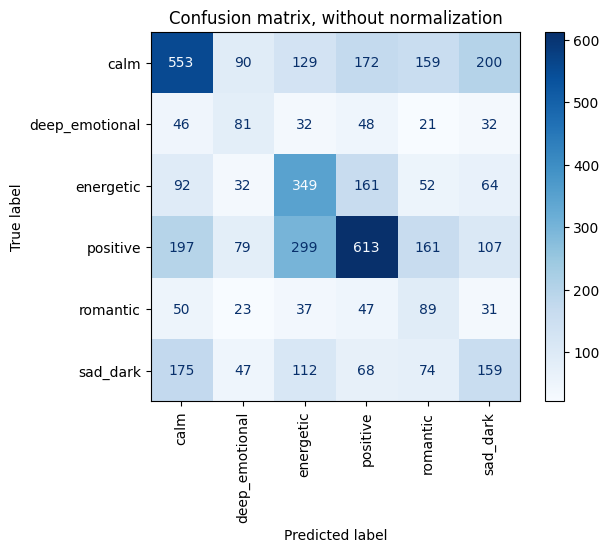

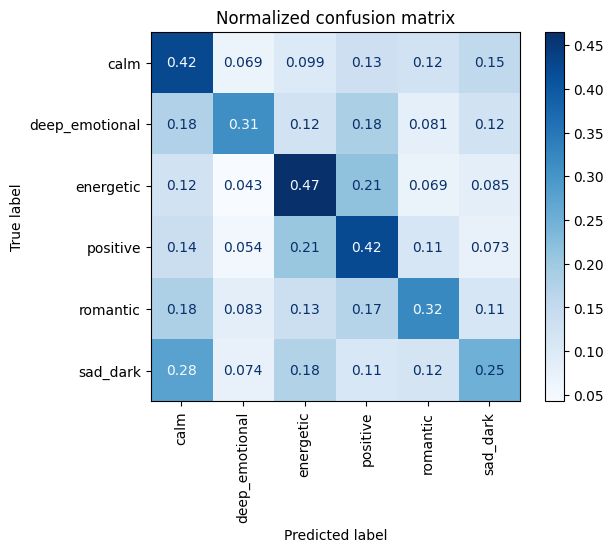

In [17]:
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]

for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
        xticks_rotation='vertical'
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

Вывод:
1. Хуже всего попадали в малонаполненные классы (sad_dark, romantic, deep_emotional) 
2. С какими классами часто путали:
    - sad_dark c calm и energetic
    - romantic c calm и positive
    - deep_emotional c calm и positive
    - positive с energetic и наоброт
3. Причины, по которым присваивали неверный класс:
    - аудио-фичи для указанных классов сильно пересекались и по смыслу классы похожи
    - при этом в аудио не было лирики -> по словам легче определить настроение
    - в оригинальной разметке трек мог принадлежать к нескольким классам настроения, а мы брали первый по частотности
    - не идеальная разметка при агрегировании настроений в крупные классы

### Примеры классификации с ошибкой

In [19]:
df_errors = X_test.copy()

df_errors['pred_label'] = preds[:, 0]
df_errors['true_label'] = y_test
df_errors['probas'] = probas.tolist()
df_errors['mood_classes'] = mood_classes

df_errors['false_pred'] = (df_errors['true_label'] != df_errors['pred_label']).astype(int)
df_errors['probas'] = df_errors['probas'].apply(lambda x: [round(i, 3) for i in x])

In [25]:
df_errors

,0_Autocorrelation,0_Centroid,0_ECDF Percentile Count_0,0_ECDF Percentile_0,0_Entropy,0_Histogram mode,0_Interquartile range,0_Kurtosis,0_Max,0_Mean absolute diff,...,chroma_std_11,chroma_std_12,arousal,dominance,valence,pred_label,true_label,probas,mood_classes,false_pred
10264,34.0,16.290369,258.0,0.173999,1.000000,0.233087,0.066254,1.594153,0.423783,0.013550,...,0.235180,0.350456,-0.026418,-0.006966,0.026107,romantic,romantic,"[0.086, 0.053, 0.103, 0.149, 0.521, 0.088]","[commercial, romantic, love]",0
5339,15.0,18.626980,258.0,0.066201,1.000000,0.071196,0.124102,-0.001450,0.474592,0.012956,...,0.214111,0.247613,-0.022040,0.024324,0.009873,sad_dark,deep_emotional,"[0.194, 0.221, 0.185, 0.06, 0.065, 0.274]","[emotional, film]",1
8968,6.0,17.504537,258.0,0.111147,0.997512,0.178808,0.096891,-0.547300,0.325105,0.016781,...,0.107043,0.209267,-0.038684,-0.001087,0.011223,positive,positive,"[0.094, 0.052, 0.047, 0.664, 0.106, 0.038]","[commercial, background, upbeat, happy]",0
11553,4.0,15.368613,258.0,0.024505,1.000000,0.039451,0.108204,-0.448324,0.237727,0.016652,...,0.285716,0.319559,-0.030768,0.007513,0.001796,positive,positive,"[0.137, 0.12, 0.256, 0.364, 0.028, 0.096]",[happy],0
2478,7.0,12.558225,258.0,0.070473,1.000000,0.096321,0.072245,0.859009,0.360297,0.011418,...,0.200381,0.423629,-0.014740,0.009442,0.011791,positive,calm,"[0.216, 0.041, 0.076, 0.301, 0.085, 0.281]","[calm, romantic, action]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13942,18.0,15.413017,258.0,0.050855,1.000000,0.323954,0.280340,-1.031407,0.498387,0.013201,...,0.205974,0.170972,-0.048054,0.015862,0.007965,sad_dark,energetic,"[0.244, 0.095, 0.094, 0.198, 0.092, 0.277]","[cool, sexy]",1
710,13.0,19.936878,258.0,0.056095,0.984058,0.097529,0.070718,-0.112818,0.278654,0.015150,...,0.267230,0.286141,-0.002942,0.008422,0.001176,romantic,positive,"[0.087, 0.106, 0.187, 0.186, 0.326, 0.108]",[positive],1
8649,43.0,15.781891,258.0,0.111184,0.969000,0.134299,0.023445,6.650161,0.179066,0.004608,...,0.123431,0.241816,-0.010691,-0.010342,0.023252,positive,calm,"[0.181, 0.095, 0.233, 0.267, 0.098, 0.126]",[meditative],1
3528,4.0,13.969528,258.0,0.105771,0.997512,0.156232,0.230513,-0.752727,0.624928,0.037963,...,0.278672,0.365919,-0.014531,0.008231,0.007749,positive,energetic,"[0.16, 0.142, 0.12, 0.291, 0.188, 0.099]",[groovy],1


In [29]:
error_sampled = df_errors[df_errors['false_pred'] == 1].sample(10, random_state=42)
error_sampled_idx = error_sampled.index

In [30]:
# ['calm' 'deep_emotional' 'energetic' 'positive' 'romantic' 'sad_dark'] - для вероятностей

error_sampled[['pred_label', 'true_label', 'probas', 'mood_classes']]

,pred_label,true_label,probas,mood_classes
6605,sad_dark,deep_emotional,"[0.095, 0.026, 0.274, 0.162, 0.144, 0.299]",[emotional]
3013,calm,sad_dark,"[0.233, 0.19, 0.101, 0.188, 0.086, 0.203]",[dark]
1083,calm,positive,"[0.242, 0.135, 0.227, 0.152, 0.073, 0.17]",[melodic]
13710,energetic,positive,"[0.113, 0.089, 0.301, 0.235, 0.158, 0.103]","[motivational, positive, happy]"
8406,sad_dark,romantic,"[0.177, 0.176, 0.135, 0.159, 0.057, 0.296]",[romantic]
1688,positive,romantic,"[0.104, 0.201, 0.234, 0.28, 0.099, 0.083]","[love, sexy]"
2150,energetic,deep_emotional,"[0.179, 0.101, 0.289, 0.174, 0.133, 0.123]",[emotional]
8510,energetic,positive,"[0.054, 0.045, 0.438, 0.337, 0.044, 0.083]","[christmas, funny, happy]"
9675,calm,energetic,"[0.231, 0.139, 0.138, 0.199, 0.123, 0.168]","[epic, film]"
7076,calm,positive,"[0.316, 0.173, 0.045, 0.098, 0.102, 0.267]","[movie, melodic]"


### Lime

In [44]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_test.values, 
    feature_names=X_test.columns, 
    class_names=loaded_model.classes_, 
    discretize_continuous=True)

In [32]:
error_sampled_idx

Index([6605, 3013, 1083, 13710, 8406, 1688, 2150, 8510, 9675, 7076], dtype='int64')

In [46]:
true_label_idx

1

In [48]:
loaded_model.classes_

array(['calm', 'deep_emotional', 'energetic', 'positive', 'romantic',
       'sad_dark'], dtype=object)

Выводы:
- Трек 1: спрогнозировали класс sad_dark, так как относительно значение 0_Negative turning points - это указывает на мелонхоличность и затухание, а также dominance - энергичность / мощность. На более низкую вероятность принадлежать правильному классу повлияла  более сильная потворяемость (0_Autocorrelation) и не изменчивость трека (0_Median diff), но по своей логике классы и правда достаточно похожи
- Трек 2: вероятности предсказанного и настроящего класса очень близки, но основной признак, который склонил к неправильному классу - это mfcc_mean_3 > 23.69. И снова классы sad_dark и calm очень близки
- Трек 3: на предсказание неверного класса повлияла высокая повторяемость трека 0_Autocorrelation > 58.00, а 0_Negative turning points > 198.00 снизило вероятность верного (затухание), так как это больше характеристики спокойных треков
- Трек 4: позитивный класс и энергичный могут сильно пересекаться по признакам, mfcc_std_1 > 101.99 склонил к предсказанию энергичного класса
- Трек 5: valence <= 0.00 уменьшило вероятность правильного класса (романтичное настроение), так как негативные значения скорее отвечают за грусть, что на самом деле не противоречит романтичному настроению
- Трек 6: аналогично 5, но в сторону позитивного (неверного) класса склонил признак 0_Neighbourhood peaks > 56.00, что указывает на танцевальность трека,но не противоречит позитивному
- Трек 7: получили energetic вместо deep_emotional, так как mfcc_std_1 > 101.99 и mfcc_mean_3 <= -12.39 сильно повысили вероятность энергичного класса. Глубокие эмоциональные треки могут также сильно пересекаться с энергичными по своей эмоциальной окраске
- Трек 8: ошиблись с positive на energetic — признак mfcc_std_1 <= 60.72 снизил вероятность правильного класса, а mfcc_mean_1 > -142.86 добавил энергии. Позитив и энергичность могут быть сложно различимыми
- Трек 9: предсказали calm вместо energetic, хотя mfcc_mean_3 <= -12.39 поддерживал именно energetic класс, в predicted он дал сильный отрицательный вклад в спокойный. Классы calm и energetic противоположны, но здесь признаки сработали неоднозначно
- Трек 10: получили calm вместо positive, так как mfcc_mean_1 <= -303.83 и mfcc_mean_5 <= -1.39 перевесили в сторону спокойствия, а 0_Negative turning points <= 148.00 (меньшее затухания) не смог "удержать" позитивный класс

In [53]:
for i, idx in enumerate(error_sampled_idx):

    true_label = error_sampled.loc[idx, 'true_label']
    pred_label = error_sampled.loc[idx, 'pred_label']

    class_names_ls = list(class_names)
    
    true_label_idx = class_names_ls.index(true_label)
    pred_label_idx = class_names_ls.index(pred_label)

    exp = explainer.explain_instance(X_test.loc[idx].values, loaded_model.predict_proba, num_features=5, top_labels=6)
    
    print('-'*50)
    print(f'For df_index={idx} и i={i}')
    print (f'Explanation for true class={class_names[true_label_idx]}')
    print ('\n'.join(map(str, exp.as_list(label=true_label_idx))))
    print()
    print (f'Explanation for predicted class={class_names[pred_label_idx]}')
    print ('\n'.join(map(str, exp.as_list(label=pred_label_idx))))

--------------------------------------------------
For df_index=6605 и i=0
Explanation for true class=deep_emotional
('0_Median diff > -0.00', -0.016894340865721898)
('0_Autocorrelation > 58.00', -0.01610404916406513)
('mfcc_mean_4 > 32.94', -0.014582834999119826)
('0_Negative turning points > 198.00', 0.013140042835060943)
('99.38 < tempo <= 117.45', 0.01305451879706882)

Explanation for predicted class=sad_dark
('0_Negative turning points > 198.00', 0.027522863242130977)
('dominance > 0.02', 0.022742866149944023)
('0_Neighbourhood peaks > 56.00', -0.01733174914335225)
('0_Median diff > -0.00', 0.016103510631918196)
('valence > 0.02', -0.015602629781606831)
--------------------------------------------------
For df_index=3013 и i=1
Explanation for true class=sad_dark
('mfcc_mean_3 > 23.69', -0.030790057649779455)
('tempo <= 99.38', 0.023682806570472135)
('bandwidth_mean <= 1262.50', 0.019725704080710248)
('0_Neighbourhood peaks > 56.00', -0.017665781351479507)
('valence > 0.02', -0.016